
#Project NLP | Business Case: Automated Customer Reviews

##Task 0. Preprocessing. Map Star Ratings to Sentiment Classes

###Mapping Star Ratings to Sentiment Classes

Since the dataset contains star ratings (1 to 5), you should map them to three sentiment classes as follows:
Star Rating



1 - 2    -->      Negative

3       -->       Neutral

4 - 5    -->      Positive



In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from transformers import TFDistilBertForSequenceClassification, DistilBertTokenizer
from transformers import RobertaTokenizer, TFRobertaForSequenceClassification
from transformers import BertTokenizer, TFBertForSequenceClassification
from tf_keras.optimizers import Adam
from tf_keras.callbacks import ModelCheckpoint, EarlyStopping

### I choose to work on this data (Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv) which is from hugging face

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datafiniti/consumer-reviews-of-amazon-products")

print("Path to dataset files:", path)
import os

# List all files in the directory
for file in os.listdir(path):
    print(file)

df1 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))
df2 = pd.read_csv(os.path.join(path, "Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))


Path to dataset files: /kaggle/input/consumer-reviews-of-amazon-products
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv
1429_1.csv
Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv


In [3]:
df1.tail()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
28327,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,5,http://reviews.bestbuy.com/3545/5620410/review...,I got 2 of these for my 8 yr old twins. My 11 ...,Xmas gift,Mom2twinsplus1,http://reviews.bestbuy.com/3545/5620410/review...
28328,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,4,http://reviews.bestbuy.com/3545/5620410/review...,I bought this for my niece for a Christmas gif...,yes it is a great tablet.,fireman21,http://reviews.bestbuy.com/3545/5620410/review...
28329,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,5,http://reviews.bestbuy.com/3545/5620410/review...,"Very nice for light internet browsing, keeping...",You get a lot for the price!,suzannalicious,http://reviews.bestbuy.com/3545/5620410/review...
28330,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,5,http://reviews.bestbuy.com/3545/5620410/review...,This Tablet does absolutely everything I want!...,You get the entire World for less than $100!,SandyJ,http://reviews.bestbuy.com/3545/5620410/review...
28331,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,True,NaN,0.0,4,http://reviews.bestbuy.com/3545/5620410/review...,"At ninety dollars, the expectionations are low...",You get what your paying for,Hung,http://reviews.bestbuy.com/3545/5620410/review...


In [4]:
df2.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-09-18T00:00:00Z,2017...",False,NaN,0,3,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-07-07T00:00:00Z,2017...",True,NaN,0,5,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,4,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...
3,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-10-09T00:00:00Z,True,177283626.0,3,5,https://redsky.target.com/groot-domain-api/v1/...,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,https://www.newegg.com/Product/Product.aspx%25...
4,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,5,https://reviews.bestbuy.com/3545/5442403/revie...,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,https://www.newegg.com/Product/Product.aspx%25...


###combine reviews.text and review.title in combined df dataset, and print an example

In [5]:
# Combine the DataFrames
df3 = pd.concat([df1, df2], ignore_index=True)

# Remove duplicate rows
df3.drop_duplicates(inplace=True)

# Optional: reset index after dropping duplicates
df3.reset_index(drop=True, inplace=True)

In [6]:
df3['reviews.text'] = df3['reviews.title'].fillna('') + ' ' + df3['reviews.text'].fillna('')


In [7]:
print(df3['reviews.text'][100])

A great value for those that run through batteries like air! As a teacher, I need tons of batteries, but I refused to spend excessive amounts on them, so I figured this was the best option! They are long-lasting, worth the money, cute (if that even matters, lol)! You won't find a deal like this in stores!I highly recommend!


In [8]:
df3.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs,reviews.dateAdded
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,... 3 of them and one of the item is bad quali...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht...",NaN
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,... always the less expensive way to go for pr...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht...",NaN
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,... are not Duracell but for the price i am ha...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht...",NaN
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,... as well as name brand batteries at a much ...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht...",NaN
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,... batteries are very long lasting the price ...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht...",NaN


In [9]:
df3.isnull().sum()

,0
id,0
dateAdded,0
dateUpdated,0
name,0
asins,0
brand,0
categories,0
primaryCategories,0
imageURLs,0
keys,0


In [10]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33237 entries, 0 to 33236
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   33237 non-null  object 
 1   dateAdded            33237 non-null  object 
 2   dateUpdated          33237 non-null  object 
 3   name                 33237 non-null  object 
 4   asins                33237 non-null  object 
 5   brand                33237 non-null  object 
 6   categories           33237 non-null  object 
 7   primaryCategories    33237 non-null  object 
 8   imageURLs            33237 non-null  object 
 9   keys                 33237 non-null  object 
 10  manufacturer         33237 non-null  object 
 11  manufacturerNumber   33237 non-null  object 
 12  reviews.date         33237 non-null  object 
 13  reviews.dateSeen     33237 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  20991 non-null 

##EDA

In [11]:
# distribution of rating
df3['reviews.rating'].value_counts().sort_index(ascending=False)

,count
reviews.rating,
5,23309
4,6836
3,1399
2,669
1,1024


###imbalance data


<ipython-input-12-071e381d4db2>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df3['reviews.rating'], palette='Blues')


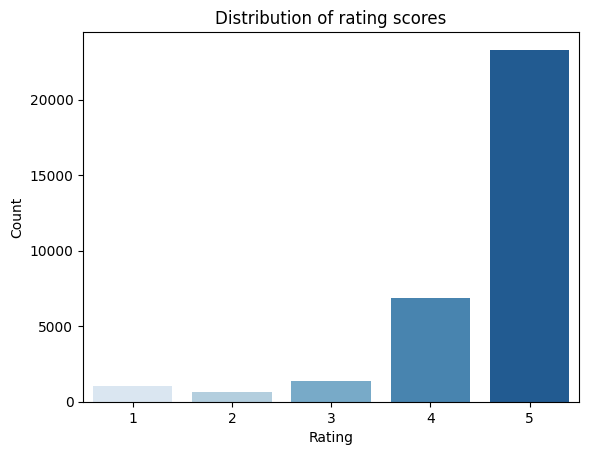

In [12]:
# distribution of rating
sns.countplot(x = df3['reviews.rating'], palette='Blues')

plt.title('Distribution of rating scores')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [13]:




# Define a function to map star ratings to sentiment classes
def map_star_rating_to_sentiment(star_rating):
    if star_rating in [1, 2]:
        return 'Negative'
    elif star_rating == 3:
        return 'Neutral'
    elif star_rating in [4, 5]:
        return 'Positive'
    else:
        return 'Unknown'  # Handle any other cases if needed

# Apply the function to create a new column 'Sentiment'
df3['Sentiment'] = df3['reviews.rating'].apply(map_star_rating_to_sentiment)

# Show a sample of the dataset
print(df3[['reviews.rating', 'Sentiment']].head())


   reviews.rating Sentiment
0               3   Neutral
1               4  Positive
2               5  Positive
3               5  Positive
4               5  Positive


In [14]:
df3['Sentiment'].value_counts()

,count
Sentiment,
Positive,30145
Negative,1693
Neutral,1399


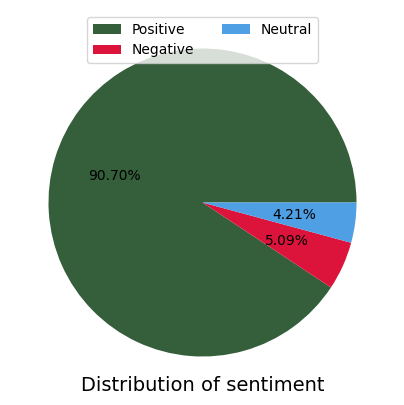

In [15]:
plt.figure(figsize = (5,5))

labels = ['Positive', 'Negative','Neutral']
colors = colors = ['#355E3B', '#DC143C', '#4E9FE3']

plt.pie(df3['Sentiment'].value_counts(), autopct='%0.2f%%',colors=colors)

plt.title('Distribution of sentiment', size=14, y=-0.01)
plt.legend(labels, ncol=2, loc=9)
plt.show()

###Downsample Positive Class

In [16]:
from sklearn.utils import resample

# Separate by class
df_positive = df3[df3['Sentiment'] == 'Positive']
df_negative = df3[df3['Sentiment'] == 'Negative']
df_neutral = df3[df3['Sentiment'] == 'Neutral']

# Downsample Positive
df_positive_downsampled = resample(df_positive,
                                   replace=False,
                                   n_samples=8000,  # Adjust this number as needed
                                   random_state=42)

# Combine into a new balanced dataframe
df = pd.concat([df_positive_downsampled, df_negative, df_neutral])

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [17]:
df.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs,reviews.dateAdded,Sentiment
0,AWFUWc8THh53nbDRF6YO,2018-02-02T02:30:22Z,2018-10-15T16:03:30Z,Amazon Echo Show Alexa-enabled Bluetooth Speak...,B010CEHQTG,Amazon,"Computers,Amazon Echo,Virtual Assistant Speake...","Electronics,Hardware",https://static.bhphoto.com/images/images500x50...,"echoshowwhite/ameshowwht,amazon/b010cehqtg,848...",...,NaN,0.0,4,https://reviews.bestbuy.com/3545/5875664/revie...,Gift to client Added screen a great features v...,Gift to client,C3nturion1,https://reviews.bestbuy.com/3545/5875664/revie...,NaN,Positive
1,AVpfpK8KLJeJML43BCuD,2017-01-04T03:51:17Z,2019-04-17T16:06:27Z,Amazon Tap Smart Assistant Alexaenabled (black...,B01BH83OOM,Amazon,"Amazon Echo,Home Theater & Audio,MP3 MP4 Playe...",Electronics,https://i.ebayimg.com/images/g/tnUAAOSwESdcftG...,"amazonecho/b01bh83oom,amazonamazontapportableb...",...,NaN,0.0,2,http://reviews.bestbuy.com/3545/5097300/review...,Not impressed Just really thought it would hav...,Not impressed,Pogera,http://reviews.bestbuy.com/3545/5097300/review...,NaN,Negative
2,AVph0EeEilAPnD_x9myq,2017-01-11T06:58:33Z,2019-02-25T02:05:06Z,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",B018Y22C2Y,Amazon,"Computers,Fire Tablets,Electronics Features,Co...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,amazonfirekidsedition16gb5thgen2015releaseblue...,...,NaN,0.0,5,http://reviews.bestbuy.com/3545/5026000/review...,Educational and Fun The tablet offered my son ...,Educational and Fun,Andre50,http://reviews.bestbuy.com/3545/5026000/review...,NaN,Positive
3,AVpe7xlELJeJML43ypLz,2015-12-03T01:23:41Z,2019-04-24T02:17:42Z,AmazonBasics AA Performance Alkaline Batteries...,"B00QWO9P0O,B01IB83NZG,B00MNV8E0C",Amazonbasics,"AA,AAA,Electronics Features,Health,Electronics...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,amazonbasicsaaperformancealkalinebatteries48co...,...,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,Three Stars we'll see how they hold up,Three Stars,ByDonald L. Mansell,"https://www.barcodable.com/upc/841710106411,ht...",NaN,Neutral
4,AVqkIhxunnc1JgDc3kg_,2017-03-06T14:59:43Z,2019-02-23T02:49:38Z,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",B018T075DC,Amazon,"Fire Tablets,Tablets,All Tablets,Amazon Tablet...",Electronics,https://www.upccodesearch.com/images/barcode/0...,"amazon/b018t075dc,firehd8tabletwithalexa8hddis...",...,NaN,0.0,5,http://reviews.bestbuy.com/3545/5620410/review...,I'd give it a 10 star rating! Excellent value ...,I'd give it a 10 star rating!,vickybee,http://reviews.bestbuy.com/3545/5620410/review...,NaN,Positive


In [18]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,8000
Negative,1693
Neutral,1399


In [19]:
# Features (X) and target variable (y)
X = df['reviews.text']


# Convert text labels to integer labels using LabelEncoder
label_encoder = LabelEncoder()

y= label_encoder.fit_transform(df['Sentiment'])

In [20]:
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


In [21]:
y

array([2, 0, 2, ..., 2, 2, 2])

In [22]:
# Compute class weights
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y),
                                     y=y)

# Map class weights to a dictionary
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(2.1838944674148455), 1: np.float64(2.6428401238980226), 2: np.float64(0.46216666666666667)}


##Task 1. Classification with pre-trained models.

Select the model

Finetune it

Evaluate

Save the best model

Model Building

For classifying customer reviews into positive, negative, or neutral, use pretrained transformer-based models to leverage powerful language representations without training from scratch.

Suggested Models

distilbert-base-uncased – Lightweight and fast, ideal for limited resources.

bert-base-uncased – A strong general-purpose model for sentiment analysis.

roberta-base – More robust to nuanced sentiment variations.

nlptown/bert-base-multilingual-uncased-sentiment – Handles multiple languages, useful for diverse datasets.

cardiffnlp/twitter-roberta-base-sentiment – Optimized for short texts like social media reviews.

Explore models on Hugging Face and experiment with fine-tuning to improve accuracy.

###bert-base-uncased with weight adjusment

In [23]:
# Manually adjusted class weights
class_weights_dict = {
    0: 2.0,   # Negative class weight (relatively higher than Positive)
    1: 4.0,   # Neutral class weight (highest weight to focus most)
    2: 1.0    # Positive class weight (lowest weight)
}

print("Adjusted Class Weights:", class_weights_dict)

Adjusted Class Weights: {0: 2.0, 1: 4.0, 2: 1.0}


In [27]:


# Load tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

# Tokenize the data
inputs = tokenizer(list(X), padding=True, truncation=True, return_tensors='tf', max_length=128)

# Extract input IDs and attention mask
input_ids_np = inputs['input_ids'].numpy()
attention_mask_np = inputs['attention_mask'].numpy()

# Train-test split
X_train_ids, X_val_ids, X_train_mask, X_val_mask, y_train, y_val = train_test_split(
    input_ids_np, attention_mask_np, y, test_size=0.2, stratify=y
)

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': X_train_ids, 'attention_mask': X_train_mask}, y_train)).batch(16)

val_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': X_val_ids, 'attention_mask': X_val_mask}, y_val)).batch(16)

# Compile the model
model_bert.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Callbacks
checkpoint_cb = ModelCheckpoint(
    filepath='bert_best_model.weights.h5',           # folder name
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,         # recommended for HF models
    mode='max',
    verbose=1
)

callbacks = [checkpoint_cb]

# Train the model
model_bert.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

# Save the Hugging Face model and tokenizer
model_bert.save_pretrained('bert_model')
tokenizer.save_pretrained('bert_model')

# Save the TensorFlow model in SavedModel format (this works for subclassed models)
model_bert.save('bert_model_tensorflow', save_format='tf')


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/10
555/555 [==============================] - ETA: 0s - loss: 0.5649 - accuracy: 0.8693
Epoch 1: val_accuracy improved from -inf to 0.91888, saving model to bert_best_model.weights.h5


/usr/local/lib/python3.11/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


555/555 [==============================] - 99s 107ms/step - loss: 0.5649 - accuracy: 0.8693 - val_loss: 0.2392 - val_accuracy: 0.9189
Epoch 2/10
555/555 [==============================] - ETA: 0s - loss: 0.2485 - accuracy: 0.9480
Epoch 2: val_accuracy improved from 0.91888 to 0.93736, saving model to bert_best_model.weights.h5
555/555 [==============================] - 40s 72ms/step - loss: 0.2485 - accuracy: 0.9480 - val_loss: 0.2004 - val_accuracy: 0.9374
Epoch 3/10
555/555 [==============================] - ETA: 0s - loss: 0.1306 - accuracy: 0.9744
Epoch 3: val_accuracy improved from 0.93736 to 0.94322, saving model to bert_best_model.weights.h5
555/555 [==============================] - 40s 72ms/step - loss: 0.1306 - accuracy: 0.9744 - val_loss: 0.2130 - val_accuracy: 0.9432
Epoch 4/10
555/555 [==============================] - ETA: 0s - loss: 0.0869 - accuracy: 0.9844
Epoch 4: val_accuracy improved from 0.94322 to 0.94457, saving model to bert_best_model.weights.h5
555/555 [======

In [28]:
y_pred_logits = model_bert.predict(val_dataset).logits
y_pred = np.argmax(y_pred_logits, axis=1)
y_pred

139/139 [==============================] - 7s 27ms/step


array([1, 0, 2, ..., 2, 2, 2])

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Confusion Matrix:
 [[ 312   17   10]
 [  34  221   25]
 [   5   34 1561]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90       339
           1       0.81      0.79      0.80       280
           2       0.98      0.98      0.98      1600

    accuracy                           0.94      2219
   macro avg       0.89      0.90      0.89      2219
weighted avg       0.94      0.94      0.94      2219



In [ ]:
# Load tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model_distilbert = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)

# Tokenize the data
inputs = tokenizer(list(X), padding=True, truncation=True, return_tensors='tf', max_length=128)

# Convert TensorFlow tensors to numpy arrays for train_test_split
input_ids_np = inputs['input_ids'].numpy()

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(input_ids_np, y, test_size=0.2, stratify=y)

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(16)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(16)
#optimizer = Adam(learning_rate=2e-5)
# Compile the model
from tf_keras.optimizers import Adam
model_distilbert.compile(optimizer = Adam(learning_rate=2e-5),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train the model with class weights
model_distilbert.fit(train_dataset, epochs=10, validation_data=val_dataset)




tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/10
555/555 [==============================] - 54s 63ms/step - loss: 0.3964 - accuracy: 0.8547 - val_loss: 0.2821 - val_accuracy: 0.8959
Epoch 2/10
555/555 [==============================] - 18s 33ms/step - loss: 0.1930 - accuracy: 0.9328 - val_loss: 0.2293 - val_accuracy: 0.9220
Epoch 3/10
555/555 [==============================] - 18s 33ms/step - loss: 0.1111 - accuracy: 0.9670 - val_loss: 0.2576 - val_accuracy: 0.9193
Epoch 4/10
555/555 [==============================] - 19s 33ms/step - loss: 0.0776 - accuracy: 0.9778 - val_loss: 0.2434 - val_accuracy: 0.9301
Epoch 5/10
555/555 [==============================] - 19s 34ms/step - loss: 0.0524 - accuracy: 0.9847 - val_loss: 0.2438 - val_accuracy: 0.9347
Epoch 6/10
555/555 [==============================] - 19s 34ms/step - loss: 0.0409 - accuracy: 0.9868 - val_loss: 0.2931 - val_accuracy: 0.9306
Epoch 7/10
555/555 [==============================] - 19s 34ms/step - loss: 0.0261 - accuracy: 0.9923 - val_loss: 0.3118 - val_accuracy:

In [ ]:
y_pred_logits = model_distilbert.predict(val_dataset).logits
y_pred = np.argmax(y_pred_logits, axis=1)
y_pred

139/139 [==============================] - 3s 13ms/step


array([2, 2, 2, ..., 1, 2, 2])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Confusion Matrix:
 [[ 315   17    7]
 [  24  209   47]
 [   8   28 1564]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       339
           1       0.82      0.75      0.78       280
           2       0.97      0.98      0.97      1600

    accuracy                           0.94      2219
   macro avg       0.90      0.88      0.89      2219
weighted avg       0.94      0.94      0.94      2219



In [ ]:
# Load tokenizer and model for RoBERTa
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = TFRobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=3)

# Tokenize the data
inputs = tokenizer(list(X), padding=True, truncation=True, return_tensors='tf', max_length=128)

# Extract input IDs and attention mask
input_ids_np = inputs['input_ids'].numpy()
attention_mask_np = inputs['attention_mask'].numpy()

# Train-test split
X_train_ids, X_val_ids, X_train_mask, X_val_mask, y_train, y_val = train_test_split(
    input_ids_np, attention_mask_np, y, test_size=0.2, stratify=y
)

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': X_train_ids, 'attention_mask': X_train_mask}, y_train)).batch(16)

val_dataset = tf.data.Dataset.from_tensor_slices((
    {'input_ids': X_val_ids, 'attention_mask': X_val_mask}, y_val)).batch(16)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Callbacks
checkpoint_cb = ModelCheckpoint(
    filepath='roberta_best_model.weights.h5',           # folder name
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,         # recommended for HF models
    mode='max',
    verbose=1
)

callbacks = [checkpoint_cb]

# Train the model
model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

# Save final model and tokenizer
model.save_pretrained('roberta_model')
tokenizer.save_pretrained('roberta_model')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

Epoch 1/10
555/555 [==============================] - ETA: 0s - loss: 0.5856 - accuracy: 0.8037
Epoch 1: val_accuracy improved from -inf to 0.91077, saving model to roberta_best_model.weights.h5


/usr/local/lib/python3.11/dist-packages/transformers/generation/tf_utils.py:465: UserWarning: `seed_generator` is deprecated and will be removed in a future version.
  warnings.warn("`seed_generator` is deprecated and will be removed in a future version.", UserWarning)


555/555 [==============================] - 107s 120ms/step - loss: 0.5856 - accuracy: 0.8037 - val_loss: 0.2727 - val_accuracy: 0.9108
Epoch 2/10
555/555 [==============================] - ETA: 0s - loss: 0.3258 - accuracy: 0.9057
Epoch 2: val_accuracy did not improve from 0.91077
555/555 [==============================] - 36s 66ms/step - loss: 0.3258 - accuracy: 0.9057 - val_loss: 0.3170 - val_accuracy: 0.9022
Epoch 3/10
555/555 [==============================] - ETA: 0s - loss: 0.2173 - accuracy: 0.9363
Epoch 3: val_accuracy improved from 0.91077 to 0.92384, saving model to roberta_best_model.weights.h5
555/555 [==============================] - 39s 70ms/step - loss: 0.2173 - accuracy: 0.9363 - val_loss: 0.2817 - val_accuracy: 0.9238
Epoch 4/10
555/555 [==============================] - ETA: 0s - loss: 0.1613 - accuracy: 0.9517
Epoch 4: val_accuracy improved from 0.92384 to 0.92744, saving model to roberta_best_model.weights.h5
555/555 [==============================] - 39s 71ms/step

('roberta_model/tokenizer_config.json',
 'roberta_model/special_tokens_map.json',
 'roberta_model/vocab.json',
 'roberta_model/merges.txt',
 'roberta_model/added_tokens.json')

In [ ]:
y_pred_logits = model.predict(val_dataset).logits
y_pred = np.argmax(y_pred_logits, axis=1)
y_pred

139/139 [==============================] - 7s 26ms/step


array([1, 2, 2, ..., 0, 2, 2])

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_val, y_pred))


Confusion Matrix:
 [[ 305   22   12]
 [  22  222   36]
 [   6   21 1573]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91       339
           1       0.84      0.79      0.81       280
           2       0.97      0.98      0.98      1600

    accuracy                           0.95      2219
   macro avg       0.91      0.89      0.90      2219
weighted avg       0.95      0.95      0.95      2219



##Task 2. Product Category Clustering

Objective: Simplify the dataset by clustering product categories into 4-6 meta-categories.

Task: Create a model to group all reviews into 4-6 broader categories. Example suggestions:

Ebook readers

Batteries

Accessories (keyboards, laptop stands, etc.)

Non-electronics (Nespresso pods, pet carriers, etc.)

Note: Analyze the dataset in depth to determine the most appropriate categories.

How to Solve with Transformers

Extract product category text from your dataset

Generate embeddings using a transformer model (like BERT, RoBERTa, or Sentence-BERT)

Apply clustering to these embeddings (for example K-means with k=4-6)

Analyze and label the resulting clusters

In [34]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

In [35]:
# Step 1: Preprocess product names
df = df.dropna(subset=['name']).copy()
p_categories = df['name'].str.lower().str.replace(r'[^a-zA-Z0-9 ]', '', regex=True).unique()

# # # Step 2: Generate Sentence-BERT embeddings
model = SentenceTransformer('distilbert-base-nli-stsb-mean-tokens')
embeddings = model.encode(p_categories.tolist(), show_progress_bar=True)

# # Step 3: Apply KMeans clustering
k = 5  #Change to 4 or 6 to experiment
kmeans = KMeans(n_clusters=k, random_state=42)
p_categories_clusters = kmeans.fit_predict(embeddings)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.82k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/555 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

In [36]:
# Step 4: Assign clusters back to unique product names (p_categories)
category_df = pd.DataFrame({
    'category': p_categories,
    'cluster': p_categories_clusters
})


In [37]:
# Step 5: Analyze and label clusters
for i in range(k):
    print(f"\n🔹 Cluster {i}:")

    # Filter product names in the current cluster (based on p_categories_clusters)
    sample_names = category_df[category_df['cluster'] == i]['category'].tolist()

    # Print the first 10 product names in the cluster
    for name in sample_names:
        print(f" - {name}")



🔹 Cluster 0:
 - brand new amazon kindle fire 16gb 7 ips display tablet wifi 16 gb blue
 - amazonbasics backpack for laptops up to 17inches
 - amazonbasics 156inch laptop and tablet bag
 - amazonbasics 116inch laptop sleeve
 - expanding accordion file folder plastic portable document organizer letter size
 - amazonbasics external hard drive case

🔹 Cluster 1:
 - kindle ereader  white 6 glarefree touchscreen display wifi  includes special offers
 - kindle voyage ereader 6 highresolution display 300 ppi with adaptive builtin light pagepress sensors wifi  includes special offers
 - kindle oasis ereader with leather charging cover  merlot 6 highresolution display 300 ppi wifi  includes special offers
 - kindle voyage ereader 6 highresolution display 300 ppi with adaptive builtin light pagepress sensors free 3g  wifi  includes special offers
 - kindle oasis ereader with leather charging cover  walnut 6 highresolution display 300 ppi wifi  includes special offers
 - allnew kindle ereader  bl

In [38]:
category_df.groupby('cluster').size()

,0
cluster,
0,6
1,10
2,20
3,16
4,14


In [39]:
cluster_labels = {
    0: "Smart Speakers and TV",
    1: "Fire Tablets",
    2: "Fire Tablets kids",
    3: "Accessories and Batteries",
    4: "E-Readers"
}

# Apply human-readable labels
category_df['meta_category'] = category_df['cluster'].map(cluster_labels)

In [40]:
category_df.loc[category_df['cluster'] == 2, 'cluster'] = 1
category_df.loc[category_df['cluster'] == 3, 'cluster'] = 2
category_df.loc[category_df['cluster'] == 4, 'cluster'] = 3

In [41]:
category_df.groupby('cluster').size()

,0
cluster,
0,6
1,30
2,16
3,14


In [42]:
from sklearn.metrics import silhouette_score

score = silhouette_score(embeddings, p_categories_clusters)
print(f"Silhouette Score for k={k}: {score:.4f}")

Silhouette Score for k=5: 0.1501


##Task 3. Summarize reviews using generative AI

Objective: Summarize reviews into articles that recommend the top products for each category.

Task: Create a model that generates a short article (like a blog post) for each product category. The output should include:

Top 3 products and key differences between them.

Top complaints for each of those products.

Worst product in the category and why it should be avoided.

Consider using Pretrained Generative Models like T5, GPT-3, or BART for generating coherent and well-structured summaries. These models excel at tasks like summarization and text generation, and can be fine-tuned to produce high-quality outputs based on the extracted insights from reviews. You are encouraged to explore other Transformer-based models available on platforms like Hugging Face. Fine-tuning any of these pre-trained models on your specific dataset could further improve the relevance and quality of the generated summaries.

In [43]:
import openai
openai.api_key = os.getenv("OPENAI_API_KEY")

In [44]:
# Function to extract key complaints from reviews
def extract_complaints(reviews):
    # Here, you can use sentiment analysis or keyword extraction to find top complaints
    complaints = " ".join(reviews).lower()
    common_complaints = [word for word in ["bad", "waste", "poor", "disappointing", "uncomfortable", "not good"] if word in complaints]
    return ", ".join(set(common_complaints))

# def get_top_products_and_worst(df):
    groupped_reviews = df.groupby('name') # just group
    review_texts = groupped_reviews['reviews.text'].apply(list).reset_index() # get all the reviews for groupped products

    # get star_rating for groupped products
    star_ratings = groupped_reviews['reviews.rating'].mean()

    products_and_ratings = pd.concat([
        review_texts,
        star_ratings
    ], axis=1) # combine them together

    # Sorting products based on sentiment score
    top_products = products_and_ratings.sort_values(by='reviews.rating', ascending=False).head(3)
    worst_product = products_and_ratings.sort_values(by='reviews.rating').head(1)

    return top_products, worst_product

In [50]:
# Example of top_products and worst_product DataFrames
top_products = pd.DataFrame({
    'name': ['Product A', 'Product B', 'Product C'],
    'reviews.text': ['Great performance, good value', 'Affordable, easy to use', 'Premium features, high price']

})

worst_product = pd.DataFrame({
    'name': ['Product D'],
    'reviews.text': ['Poor build quality, unreliable']
})

# # Category name
#category_name = "Fire Tablets"

# # Call the function to generate the article
#article = generate_review_article(top_products, worst_product, category_name)

# # Display the generated article
# print(article)



In [51]:
from openai import OpenAI
from google.colab import userdata
api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=api_key)


def generate_prompt(top_products, worst_product, category_name):
  prompt = f"""
    Product Category: {category_name}
    Top 3 Products:
    1. {top_products.iloc[0]['name']}: Key features: {top_products.iloc[0]['reviews.text']}.
    2. {top_products.iloc[1]['name']}: Key features: {top_products.iloc[1]['reviews.text']}.
    3. {top_products.iloc[2]['name']}: Key features: {top_products.iloc[2]['reviews.text']}.

    Worst Product:
    {worst_product.iloc[0]['name']}: Reasons why it should be avoided: {worst_product.iloc[0]['reviews.text']}.

    Write a blog post-style recommendation article summarizing the top products in this category, highlighting their differences, key complaints, and why the worst product should be avoided.
  """
  return prompt

def generate_review_article(prompt):
    # Prepare the input prompt for OpenAI API
    # Call OpenAI API to generate the summary (using chat-based completions)
    response = client.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "system", "content": "You are a helpful assistant."},
                  {"role": "user", "content": prompt}],
        max_tokens=500,
        temperature=0.7
    )

    return response.choices[0].message.content

In [53]:

prompt = generate_prompt(top_products, worst_product,category_name)
generate_review_article(prompt)

'Title: "The Ultimate Guide to Fire Tablets: Top Choices and One to Avoid"\n\nAre you in the market for a Fire Tablet? This article will guide you through the top three options available and why you should consider each one. We will also highlight one product that may not live up to expectations. \n\nFirst on our list is Product A. It stands out due to its incredible performance, providing users with a smooth and seamless experience. Whether you are browsing, streaming, or gaming, this tablet won\'t let you down. It also offers good value for money, making it an economical choice without compromising on quality or functionality.\n\nThe second product worth considering is Product B. Its biggest selling point is its affordability. If you\'re on a budget but still looking for a tablet that can handle everyday tasks with ease, this is the one for you. Its user-friendly interface ensures you won\'t have to spend hours figuring out how to navigate it. \n\nFor those willing to splurge a bit m

##Task 4. Deploy in the cloud (AWS)

##Task 5. Prepare presentation

##Download all the models

In [30]:
import shutil
shutil.make_archive('/content/bert_model', 'zip', '/content/bert_model')


'/content/bert_model.zip'

In [31]:
from google.colab import files
files.download('/content/bert_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
shutil.make_archive('/content/bert_model_tensorflow', 'zip', '/content/bert_model_tensorflow')

'/content/bert_model_tensorflow.zip'

In [33]:
files.download('/content/bert_model_tensorflow.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>